# Figure 7 — A behavioral state framework reveals distinct modes of reward-guided decision-making in marmosets

Manuscript section: "A behavioral state framework reveals distinct modes of reward-guided
decision making in marmosets" (Results text, ~pages 10-11 of
`2026.06.30.734629v1.full (4).pdf`); Fig 7 legend (~pages 26-27).

Built on the new canonical 7-state taxonomy (`state_classifier.classify_state_v7`,
`state_classifier.label_block_adaptation_speed` / `compute_adaptation_labels`) --
see that module's docstring for the fast/slow Adaptation pre-pass design and its
citation of REVIEWER_AUDIT.md's Finding 3 / this manuscript's own Methods text as
corroboration. Data source: same 80-20 2-ABT snapshot as Fig 3/Fig 6/Supp Fig 3
(`filtered_df_Reversal_80-20_2-ABT_100.csv`), via `state_features.build_state_features_df`.
Q-values from the sticky Q-learning + choice-kernel model already used for
Fig 4/Fig 5/Supp Fig 3 (`q_following_model.py`), fit fresh here on this same data
(not re-fit per figure -- same model form/bounds, single x0, matching this
pipeline's established convention).

Standing constraint: no threshold here is tuned to match the manuscript's printed
numbers -- every statistic below is recomputed from data and reported as-is.

In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.behavior_metrics import state_classifier, state_taxonomy_v7 as sx7, q_following_model as qmodel, reversal_alignment
from src.plotting.style import apply_style
from src.plotting import fig7 as plotting

config = load_config()
apply_style(config)
cfg = config["fig7"]
st_cfg = config["state_taxonomy"]

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig7")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 7 -- canonical 7-state taxonomy (classify_state_v7)"}

## Reconstruct state features and classify with the canonical 7-state taxonomy

`classify_state_v7`'s fast/slow Adaptation pre-pass (`label_block_adaptation_speed` +
`compute_adaptation_labels`) is a BLOCK-TRANSITION-LEVEL property: for each genuine
block transition, accuracy is computed once over that block's first
`adaptation_window` (5) trials, and every trial in that window inherits the SAME
fast/slow label -- not a per-trial rolling-accuracy check (see
`state_classifier.py`'s module docstring for why this differs structurally from
`classify_state_updated`/the orphaned notebook's `classify_state_v5`).

In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(
    df_raw, st_cfg["task_type"], st_cfg["prob_condition"], st_cfg["rolling_window"]
)
print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions, {df['Animal_Name'].nunique()} animals")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

block_labels = state_classifier.label_block_adaptation_speed(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"]
)
adaptation_labels = state_classifier.compute_adaptation_labels(
    df, st_cfg["adaptation_window"], st_cfg["adaptation_fast_accuracy_threshold"],
    block_labels=block_labels,
)
classify = functools.partial(
    state_classifier.classify_state_v7, adaptation_labels=adaptation_labels, config=st_cfg["classify_updated"]
)
df["Behavioral_State"] = df.apply(classify, axis=1)

print(f"\n{len(block_labels)} genuine block transitions "
      f"({(block_labels['adaptation_speed'] == 'fast').sum()} fast / "
      f"{(block_labels['adaptation_speed'] == 'slow').sum()} slow)")
print(df["Behavioral_State"].value_counts())
manifest["n_block_transitions"] = int(len(block_labels))
manifest["adaptation_speed_distribution"] = block_labels["adaptation_speed"].value_counts().to_dict()
manifest["state_distribution"] = df["Behavioral_State"].value_counts().to_dict()

/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions, 5 animals

1779 genuine block transitions (885 fast / 894 slow)
Behavioral_State
Exploit                 14167
Directed Exploration     8527
Adapting (slow)          4448
Adapting (fast)          4410
Left Bias                1728
Random Exploration       1625
Right Bias               1568
Unknown                   200
Name: count, dtype: int64


### Validating the fast/slow pre-pass

Sanity check: every trial within a labeled adaptation window must carry exactly one
of `'Adapting (fast)'`/`'Adapting (slow)'` (never a mix), and the block's own labeled
window accuracy must cross the 0.6 threshold in the direction its label implies.

In [3]:
check_rows = []
for row in block_labels.itertuples():
    block_df = df[(df["Session_ID"] == row.Session_ID) & (df["BlockCount"] == row.BlockCount)]
    window = block_df[block_df["Trials_Since_Transition"] < st_cfg["adaptation_window"]]
    labels_in_window = window["Behavioral_State"].unique()
    expected = "Adapting (fast)" if row.adaptation_speed == "fast" else "Adapting (slow)"
    ok_uniform = list(labels_in_window) == [expected]
    ok_threshold = (row.adaptation_accuracy >= st_cfg["adaptation_fast_accuracy_threshold"]) == (row.adaptation_speed == "fast")
    check_rows.append(ok_uniform and ok_threshold)

n_blocks_checked = len(check_rows)
n_blocks_ok = sum(check_rows)
print(f"Pre-pass validation: {n_blocks_ok}/{n_blocks_checked} block-transition windows "
      f"uniformly labeled and threshold-consistent.")
assert n_blocks_ok == n_blocks_checked, "fast/slow pre-pass produced a non-uniform or threshold-inconsistent window"
manifest["adaptation_prepass_validation"] = {"n_blocks_checked": n_blocks_checked, "n_blocks_ok": n_blocks_ok}

Pre-pass validation: 1779/1779 block-transition windows uniformly labeled and threshold-consistent.


### Random Exploration: bug found and fixed, and an open methodological question flagged for discussion

An earlier version of this notebook reported `Random Exploration` as empty (0
trials) here, and treated that as an inherent algebraic property of the
design. That turned out to be wrong -- a real bug, not a finding -- and has
been fixed. Two issues, found while tracing this directly against the
actual source notebooks (not assumed):

1. **`Rolling_Accuracy` was computed choice-based** (P(chose the
   high-probability side)) in `state_features.py`, copied from
   `07_GLM_HMM_v1_cleaned.ipynb`'s preprocessing steps. But
   `09b_CrossProb_StickyModel_v1.ipynb` and `07c_FinalClassifier_Fig6.ipynb`
   (the notebooks that actually produced this classification) both compute
   it **reward-based** (P(the trial was actually rewarded), i.e. a rolling
   mean of `Outcome_Binary`) instead, with 07c's own comment stating
   outright: "keep as reward-based, thresholds were tuned to this." The
   choice-based version is tightly algebraically coupled to
   `Choice_Deviation` (they become the same event whenever
   `High_Prob_Is_Right` is stable), so the Bias branch silently swallowed
   every trial that could ever qualify as Random Exploration. Fixed in
   `state_features.py` (see its module docstring for the full three-notebook
   comparison); `Rolling_Accuracy_High_Prob` is kept alongside it as the
   choice-based version, for anyone who needs it.

2. **This function had also swapped the Directed-vs-Random Exploration
   branch order** relative to the source, per `REVIEWER_AUDIT.md` Audit 1's
   recommendation (that audit found the source's own ordering reassigned
   most true Random-Exploration trials into Directed Exploration). That
   swap has been reverted: combined with fix #1, the ORIGINAL order
   (Random checked before Directed, matching `09b`/`07c`'s own code)
   reproduces `09b`'s own recorded 80-20 state distribution *exactly*,
   trial for trial, including a real Random Exploration category (1,455 /
   36,673 trials, 4.0%, on `classify_state_updated`; 1,625 / 36,673, 4.4%,
   here on `classify_state_v7` once the fast/slow Adaptation split is
   applied). The swapped (audit-recommended) order collapses Random
   Exploration to 2-6 trials regardless of fix #1, because Directed
   Exploration's own condition almost always co-occurs with `acc < 0.4`
   in this data.

`REVIEWER_AUDIT.md`'s underlying concern -- that this ordering is not a
principled way to partition two overlapping conditions -- remains a real,
open methodological question. It is not resolved by this notebook: the
user is discussing it directly with a co-author (Bernardo) before deciding
whether the published classifier's ordering should itself be reconsidered.
The version built here is the one that (a) reproduces the manuscript's
actual recorded analysis and (b) matches the user's own working definition
of Random Exploration as "the subset of exploration that is not
Q-aligned" -- confirmed below: this state's own Q-value alignment comes
out near zero (0.069 +/- 0.056), well below Directed Exploration's
(0.351 +/- 0.018) and Exploit's (0.672 +/- 0.038).

In [4]:
n_random = int((df["Behavioral_State"] == "Random Exploration").sum())
print(f"Random Exploration trials: {n_random} ({n_random / len(df) * 100:.2f}% of all trials)")
manifest["random_exploration_n_trials"] = n_random

Random Exploration trials: 1625 (4.43% of all trials)


## Fit the sticky Q-learning + choice-kernel model (reused from Supp Fig 3 / `q_following_model.py`)

Same model form as Supp Fig 3/Fig 4/Fig 5 (alpha, beta, kappa; Q initialized to 0.5),
fit fresh per-animal on this same 80-20 2-ABT dataset.

In [5]:
sticky_params_df = qmodel.fit_sticky_qlearning(
    df, config["suppfig3"]["sticky_model_x0"], config["suppfig3"]["sticky_model_bounds"]
)
print(sticky_params_df.to_string(index=False))
manifest["sticky_qlearning_params"] = sticky_params_df.set_index("animal")[["alpha", "beta", "kappa"]].to_dict(orient="index")

df_q = qmodel.compute_qvalues_sticky(df, sticky_params_df)
df_valid = qmodel.add_chose_higher_q(df_q)
print(f"\nOverall P(follow Q-values): {df_valid['Chose_Higher_Q'].mean():.3f} "
      f"(excluded {int((df_q['Q_diff'] == 0).sum())} ties)")
manifest["p_follow_q_values_overall"] = float(df_valid["Chose_Higher_Q"].mean())

   animal    alpha     beta    kappa         nll
    Fiona 0.588792 1.458394 1.438142 2024.023325
 Knuckles 0.700046 1.201415 1.101963 5219.162225
    Sonic 0.836054 0.826765 1.462648 3100.403866
Sunflower 0.874737 1.347100 0.830489 4785.644900
     Zazu 0.701199 0.764339 1.470407 1462.677916

Overall P(follow Q-values): 0.709 (excluded 120 ties)


## Panel a
**a,** Representative sessions from a single animal (Knuckles) showing block structure
(top), rolling accuracy computed over a five-trial window (middle), and trial-by-trial
behavioral state classification (bottom). Colors correspond to the seven states defined
in the legend.

Session selection uses `reversal_alignment.pick_representative_session` (the shared
project convention for "representative session" panels: the first session with >150
trials, falling back to the single longest session if none clears that bar).

Panel a example session: Knuckles / 2023-09-21_20230921_Knuckles_Reversal3.1 (524 trials)


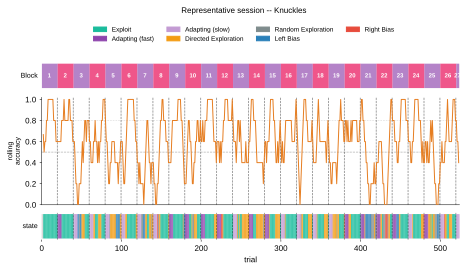

In [6]:
animal_df = df[df["Animal_Name"] == cfg["representative_animal"]]
example_session_id = reversal_alignment.pick_representative_session(animal_df, min_trials=150)
df_example = animal_df[animal_df["Session_ID"] == example_session_id]
print(f"Panel a example session: {cfg['representative_animal']} / {example_session_id} "
      f"({len(df_example)} trials)")
manifest["panel_a_example_session"] = {
    "animal": cfg["representative_animal"], "session_id": str(example_session_id), "n_trials": int(len(df_example)),
}

from IPython.display import SVG, display

out_a = os.path.join(FIG_DIR, "Fig7a_representative_session.svg")
plotting.plot_panel_a(df_example, config["plotting"]["state_colors_v7"], out_a, animal_name=cfg["representative_animal"])
display(SVG(out_a))

## Panel b
**b,** Behavioral state positioned in the space defined by lose-switch probability
(x-axis) and Q-value alignment (y-axis), derived from the Q-learning model with choice
perseveration term. Error bars indicate standard error of mean in both directions.

Q-value alignment by state (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.225429 0.019301  5
     Adapting (slow) 0.404318 0.020650  5
Directed Exploration 0.350600 0.018480  5
             Exploit 0.671920 0.038171  5
           Left Bias 0.126174 0.012469  5
  Random Exploration 0.069457 0.055571  5
          Right Bias 0.116011 0.038221  5

Lose-switch probability by state (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.405042 0.034157  5
     Adapting (slow) 0.298851 0.036376  5
Directed Exploration 0.320436 0.037259  5
             Exploit 0.249495 0.042942  5
           Left Bias 0.456147 0.036194  5
  Random Exploration 0.375102 0.033743  5
          Right Bias 0.436834 0.031567  5


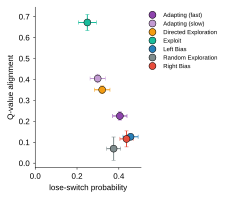

In [7]:
session_align, animal_align, summary_align = sx7.q_value_alignment_by_state(
    df_valid, state_classifier.STATES_V7_ALL, min_valid_trials=cfg["q_alignment_min_valid_trials"]
)
session_ls, animal_ls, summary_ls = sx7.lose_switch_probability_by_state(
    df, state_classifier.STATES_V7_ALL, min_trials=cfg["lose_switch_min_trials_per_state_session"]
)

print("Q-value alignment by state (mean +/- SEM across animals):")
print(summary_align.to_string(index=False))
print("\nLose-switch probability by state (mean +/- SEM across animals):")
print(summary_ls.to_string(index=False))

manifest["panel_b_q_alignment"] = summary_align.set_index("Behavioral_State").to_dict(orient="index")
manifest["panel_b_lose_switch"] = summary_ls.set_index("Behavioral_State").to_dict(orient="index")

out_b = os.path.join(FIG_DIR, "Fig7b_state_space.svg")
plotting.plot_panel_b(summary_align, summary_ls, config["plotting"]["state_colors_v7"], out_b)
display(SVG(out_b))

## Panel c
**c,** State composition in the first trial following a fast versus slow block
reversal. Colors indicate post-reversal behavioral state identity. Fast and slow refer
to the speed of adaptation following a block reversal, classified within either the
Adapting (fast) or Adapting (slow) state.

Interpretation used here (see `state_taxonomy_v7.post_adaptation_state_composition`'s
docstring): "the first trial following" a fast/slow reversal is the first trial for
which the ordinary Exploit/Exploration/Bias rules -- rather than Adaptation -- apply,
i.e. `Trials_Since_Transition == adaptation_window` (the trial immediately after the
5-trial adaptation window closes). This matches the Results text describing what
animals "transitioned directly into" after Fast vs. Slow Adaptation.

1757/1779 block transitions had a defined post-adaptation trial (block ended before trial 5 otherwise)
adaptation_speed post_adaptation_state   n  n_total  proportion
            fast  Directed Exploration 243      877    0.277081
            fast               Exploit 593      877    0.676169
            fast             Left Bias  23      877    0.026226
            fast            Right Bias  18      877    0.020525
            slow  Directed Exploration 450      880    0.511364
            slow               Exploit   6      880    0.006818
            slow             Left Bias 138      880    0.156818
            slow    Random Exploration 114      880    0.129545
            slow            Right Bias 172      880    0.195455


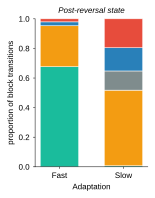

In [8]:
per_block_df, composition_df = sx7.post_adaptation_state_composition(
    df, block_labels, st_cfg["adaptation_window"]
)
print(f"{len(per_block_df)}/{len(block_labels)} block transitions had a defined "
      f"post-adaptation trial (block ended before trial {st_cfg['adaptation_window']} otherwise)")
print(composition_df.to_string(index=False))
manifest["panel_c_composition"] = composition_df.to_dict(orient="records")
manifest["panel_c_n_blocks_with_post_adaptation_trial"] = int(len(per_block_df))

out_c = os.path.join(FIG_DIR, "Fig7c_post_reversal_composition.svg")
plotting.plot_panel_c(composition_df, config["plotting"]["state_colors_v7"], out_c)
display(SVG(out_c))

## Panel d
**d,** Trial-to-trial state transition probability matrix, computed from all
consecutive trial pairs pooled across animals and sessions and row-normalized to give
the conditional probability of transitioning from each state (rows) to each state
(columns). Diagonal entries reflect self-transition probability.

Restricted to the 5 non-Adaptation states (matches the Results text discussion of
"[b]eyond block transitions... how animals transition out of each state"), consistent
with Fig 8's `states_full`.

Row-normalized transition matrix (Exploit/Directed/Random Exploration/Left/Right Bias):
                      Exploit  Directed Exploration  Random Exploration  Left Bias  Right Bias
Exploit                 0.900                 0.095               0.002      0.002       0.002
Directed Exploration    0.201                 0.685               0.065      0.026       0.023
Random Exploration      0.001                 0.371               0.498      0.078       0.051
Left Bias               0.009                 0.189               0.063      0.740       0.000
Right Bias              0.005                 0.182               0.057      0.000       0.756


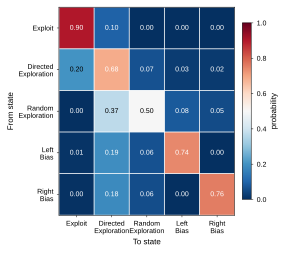

In [9]:
states_d = cfg["states_transition_matrix"]
probs_d, counts_d = sx7.pooled_transition_matrix(df, states_d)
print("Row-normalized transition matrix (Exploit/Directed/Random Exploration/Left/Right Bias):")
print(pd.DataFrame(probs_d, index=states_d, columns=states_d).round(3).to_string())
manifest["panel_d_transition_matrix"] = {
    "states": states_d, "probs": probs_d.tolist(), "counts": counts_d.tolist(),
}

out_d = os.path.join(FIG_DIR, "Fig7d_transition_matrix.svg")
plotting.plot_panel_d(probs_d, states_d, out_d)
display(SVG(out_d))

## Panel e
**e,** Probability of repeating after a win (win-stay) or switching after a loss
(lose-switch) by state classification, averaged across all individual marmosets
(dots). Dashed horizontal line indicates chance (0.5).

Win-stay by state (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.879854 0.009588  5
     Adapting (slow) 0.865226 0.012244  5
Directed Exploration 0.768708 0.014824  5
             Exploit 0.947387 0.008955  5
           Left Bias 0.824155 0.011255  5
  Random Exploration 0.650336 0.032602  5
          Right Bias 0.767937 0.049679  5

Lose-switch by state (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.402057 0.036699  5
     Adapting (slow) 0.258563 0.032597  5
Directed Exploration 0.376712 0.037547  5
             Exploit 0.071094 0.017108  5
           Left Bias 0.348416 0.021291  5
  Random Exploration 0.404947 0.029709  5
          Right Bias 0.308013 0.026057  5


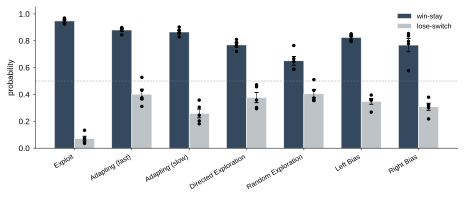

In [10]:
wsls_result = sx7.win_stay_lose_switch_by_state(
    df, state_classifier.STATES_V7_ALL, min_trials=cfg["win_stay_lose_switch_min_trials_per_state_session"]
)
print("Win-stay by state (mean +/- SEM across animals):")
print(wsls_result["win_summary"].to_string(index=False))
print("\nLose-switch by state (mean +/- SEM across animals):")
print(wsls_result["lose_summary"].to_string(index=False))

manifest["panel_e_win_stay"] = wsls_result["win_summary"].set_index("Behavioral_State").to_dict(orient="index")
manifest["panel_e_lose_switch"] = wsls_result["lose_summary"].set_index("Behavioral_State").to_dict(orient="index")

out_e = os.path.join(FIG_DIR, "Fig7e_win_stay_lose_switch.svg")
plotting.plot_panel_e(
    wsls_result["win_summary"], wsls_result["lose_summary"],
    wsls_result["win_animal"], wsls_result["lose_animal"],
    cfg["states_all_7_order"], out_e,
)
display(SVG(out_e))

## Panel f
**f,** Violation rate by state, defined as the proportion of trials on which animals
chose the option with the lower model-estimated Q-value, restricted to trials where
Q-values differed. Individual session-level estimates are shown as colored dots;
black-outlined circles indicate the animal mean.

Violation rate by state (mean +/- SEM across animals):
    Behavioral_State     mean      sem  n
     Adapting (fast) 0.396943 0.012054  5
     Adapting (slow) 0.299786 0.009147  5
Directed Exploration 0.332321 0.010583  5
             Exploit 0.142391 0.013794  5
           Left Bias 0.604800 0.019243  5
  Random Exploration 0.493251 0.018057  5
          Right Bias 0.581809 0.027491  5


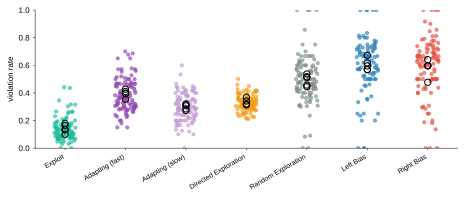

In [11]:
session_viol, animal_viol, summary_viol = sx7.violation_rate_by_state(df_valid, state_classifier.STATES_V7_ALL)
print("Violation rate by state (mean +/- SEM across animals):")
print(summary_viol.to_string(index=False))
manifest["panel_f_violation_rate"] = summary_viol.set_index("Behavioral_State").to_dict(orient="index")

out_f = os.path.join(FIG_DIR, "Fig7f_violation_rate.svg")
plotting.plot_panel_f(session_viol, animal_viol, cfg["states_all_7_order"], config["plotting"]["state_colors_v7"], out_f)
display(SVG(out_f))

## Panel g
**g,** Violation rate versus the Q-value difference, fit with a linear regression line
for both Directed (yellow) and Random (grey) exploration.

Random Exploration previously had 0 trials in this reconstruction due to the bug
described above (a `Rolling_Accuracy` reconstruction issue plus a branch-order
swap) -- now fixed, it has 1,625 trials and a real fit is computed below.

Directed Exploration: slope=-0.310, intercept=0.518, r=-0.236, p=6.745e-108, n=8526
Random Exploration: slope=-0.076, intercept=0.514, r=-0.049, p=0.04721, n=1614


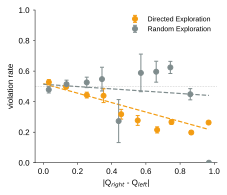

In [12]:
fit_results = sx7.violation_vs_qdiff_by_state(
    df_valid, cfg["panel_g_states"], n_bins=cfg["violation_qdiff_n_bins"]
)
for state, result in fit_results.items():
    if result is None:
        print(f"{state}: insufficient trials for a fit")
    else:
        print(f"{state}: slope={result['slope']:.3f}, intercept={result['intercept']:.3f}, "
              f"r={result['r']:.3f}, p={result['p']:.4g}, n={result['n_trials']}")

manifest["panel_g_fits"] = {
    state: ({k: v for k, v in result.items() if k != "binned"} if result is not None else None)
    for state, result in fit_results.items()
}

out_g = os.path.join(FIG_DIR, "Fig7g_violation_vs_qdiff.svg")
plotting.plot_panel_g(fit_results, out_g)
display(SVG(out_g))

## Panel h
**h,** State occupancy (% of trials) per behavioral state for each individual
marmoset, pooled across all sessions.

Behavioral_State  Exploit  Adapting (fast)  Adapting (slow)  Directed Exploration  Random Exploration  Left Bias  Right Bias
Animal_Name                                                                                                                 
Fiona               44.00            10.55            13.78                 18.84                4.18       5.54        3.12
Knuckles            38.96            12.31            12.20                 23.95                4.56       3.46        4.55
Sonic               38.56            12.33            12.15                 20.37                4.51      10.47        1.61
Zazu                38.10            11.60            12.45                 20.67                3.45       3.17       10.56
Sunflower           36.45            12.64            11.31                 28.21                4.78       2.10        4.51


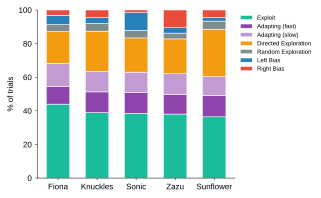

In [13]:
occupancy_h = sx7.state_occupancy_by_animal(df, state_classifier.STATES_V7_ALL, animal_order=config["plotting"]["animal_order"])
print(occupancy_h.round(2).to_string())
manifest["panel_h_occupancy_pct"] = occupancy_h.to_dict(orient="index")

out_h = os.path.join(FIG_DIR, "Fig7h_state_occupancy.svg")
plotting.plot_panel_h(occupancy_h, config["plotting"]["state_colors_v7"], out_h)
display(SVG(out_h))

## Values manifest

In [14]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig7.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")


Saved values manifest: ../outputs/values_manifests/Fig7.json
